# 📊 Notebook 01 — Exploratory Data Analysis (EDA)
## GPS Tracker Bus Sekolah — ETA Prediction
**Dataset:** Taxi Trajectory Data — ECML/PKDD 15 (Porto, Portugal)  
**Link:** https://www.kaggle.com/datasets/crailtap/taxi-trajectory

---
### 🎯 Tujuan
- Memahami struktur dan distribusi dataset
- Mengidentifikasi missing values dan outlier
- Mengekstrak fitur relevan dari koordinat GPS dan timestamp
- Menganalisis pola perjalanan berdasarkan waktu dan jarak

## 0️⃣ Mount Google Drive & Set Base Path

In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Sesuaikan dengan lokasi folder ml-eta di Google Drive kamu
BASE_PATH = '/content/drive/MyDrive/ml-eta'

import os
os.makedirs(f'{BASE_PATH}/data', exist_ok=True)
os.makedirs(f'{BASE_PATH}/models', exist_ok=True)

print(f'Drive terhubung! BASE_PATH = {BASE_PATH}')

Mounted at /content/drive
Drive terhubung! BASE_PATH = /content/drive/MyDrive/ml-eta


## 1️⃣ Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import ast
import warnings
warnings.filterwarnings('ignore')

from math import radians, sin, cos, sqrt, atan2

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('✅ Libraries loaded!')

✅ Libraries loaded!


## 2️⃣ Load Dataset

In [3]:
# Load dataset (sesuaikan path jika perlu)
# Download dari: https://www.kaggle.com/datasets/crailtap/taxi-trajectory
df_raw = pd.read_csv(f'{BASE_PATH}/data/train.csv', nrows=50000)  # ambil 50k dulu untuk eksplorasi

print(f'Shape: {df_raw.shape}')
print(f'Kolom: {df_raw.columns.tolist()}')
df_raw.head(3)

Shape: (50000, 9)
Kolom: ['TRIP_ID', 'CALL_TYPE', 'ORIGIN_CALL', 'ORIGIN_STAND', 'TAXI_ID', 'TIMESTAMP', 'DAY_TYPE', 'MISSING_DATA', 'POLYLINE']


,TRIP_ID,CALL_TYPE,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP,DAY_TYPE,MISSING_DATA,POLYLINE
0,1372636858620000589,C,NaN,NaN,20000589,1372636858,A,False,"[[-8.618643,41.141412],[-8.618499,41.141376],[..."
1,1372637303620000596,B,NaN,7.0,20000596,1372637303,A,False,"[[-8.639847,41.159826],[-8.640351,41.159871],[..."
2,1372636951620000320,C,NaN,NaN,20000320,1372636951,A,False,"[[-8.612964,41.140359],[-8.613378,41.14035],[-..."


## 3️⃣ Struktur & Info Dataset

In [4]:
print('=== INFO ===')
df_raw.info()
print('\n=== STATISTIK ===')
df_raw.describe()

=== INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TRIP_ID       50000 non-null  int64  
 1   CALL_TYPE     50000 non-null  object 
 2   ORIGIN_CALL   10784 non-null  float64
 3   ORIGIN_STAND  24434 non-null  float64
 4   TAXI_ID       50000 non-null  int64  
 5   TIMESTAMP     50000 non-null  int64  
 6   DAY_TYPE      50000 non-null  object 
 7   MISSING_DATA  50000 non-null  bool   
 8   POLYLINE      50000 non-null  object 
dtypes: bool(1), float64(2), int64(3), object(3)
memory usage: 3.1+ MB

=== STATISTIK ===


,TRIP_ID,ORIGIN_CALL,ORIGIN_STAND,TAXI_ID,TIMESTAMP
count,5.000000e+04,10784.000000,24434.000000,5.000000e+04,5.000000e+04
mean,1.373078e+18,22912.505749,30.084759,2.000035e+07,1.373078e+09
std,2.494146e+14,19663.470440,17.684437,2.120127e+02,2.494146e+05
min,1.372637e+18,2001.000000,1.000000,2.000000e+07,1.372637e+09
25%,1.372867e+18,4910.500000,15.000000,2.000017e+07,1.372867e+09
50%,1.373068e+18,16212.000000,26.000000,2.000034e+07,1.373068e+09
75%,1.373291e+18,38636.750000,47.000000,2.000052e+07,1.373291e+09
max,1.373533e+18,63882.000000,63.000000,2.000098e+07,1.373533e+09


In [5]:
# Cek missing values
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct (%)': missing_pct})
print('=== MISSING VALUES ===')
print(missing_df[missing_df['Missing'] > 0])

# Cek MISSING_DATA flag
print(f'\nTrip dengan MISSING_DATA=True: {df_raw["MISSING_DATA"].sum()} ({df_raw["MISSING_DATA"].mean()*100:.2f}%)')

=== MISSING VALUES ===
              Missing  Pct (%)
ORIGIN_CALL     39216    78.43
ORIGIN_STAND    25566    51.13

Trip dengan MISSING_DATA=True: 0 (0.00%)


## 4️⃣ Parse POLYLINE & Hitung Durasi / Jarak

In [6]:
def haversine(lon1, lat1, lon2, lat2):
    """Hitung jarak (km) antara dua koordinat GPS menggunakan formula Haversine."""
    R = 6371  # radius bumi (km)
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1
    dlat = lat2 - lat1
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    return R * 2 * atan2(sqrt(a), sqrt(1-a))

def parse_polyline(polyline_str):
    """Parse string POLYLINE menjadi list koordinat [lon, lat]."""
    try:
        coords = ast.literal_eval(polyline_str)
        return coords if len(coords) > 1 else None
    except:
        return None

def compute_trip_distance(coords):
    """Hitung total jarak perjalanan dari list koordinat GPS."""
    if coords is None or len(coords) < 2:
        return None
    total = 0
    for i in range(len(coords) - 1):
        lon1, lat1 = coords[i]
        lon2, lat2 = coords[i+1]
        total += haversine(lon1, lat1, lon2, lat2)
    return total

print('🔄 Parsing POLYLINE...')
df_raw['coords'] = df_raw['POLYLINE'].apply(parse_polyline)

# Hapus data yang MISSING_DATA=True atau POLYLINE kosong
df = df_raw[(df_raw['MISSING_DATA'] == False) & (df_raw['coords'].notna())].copy()

# Hitung durasi: (jumlah titik - 1) × 15 detik
df['n_points'] = df['coords'].apply(len)
df['duration_sec'] = (df['n_points'] - 1) * 15
df['duration_min'] = df['duration_sec'] / 60

# Hitung jarak total (km)
df['distance_km'] = df['coords'].apply(compute_trip_distance)

# Koordinat awal dan akhir
df['start_lon'] = df['coords'].apply(lambda x: x[0][0])
df['start_lat'] = df['coords'].apply(lambda x: x[0][1])
df['end_lon']   = df['coords'].apply(lambda x: x[-1][0])
df['end_lat']   = df['coords'].apply(lambda x: x[-1][1])

# Jarak lurus (haversine) dari start ke end
df['straight_dist_km'] = df.apply(
    lambda r: haversine(r['start_lon'], r['start_lat'], r['end_lon'], r['end_lat']), axis=1
)

# Kecepatan rata-rata (km/h)
df['avg_speed_kmh'] = df['distance_km'] / (df['duration_sec'] / 3600)

print(f'✅ Selesai! Total data valid: {len(df):,}')
df[['duration_min', 'distance_km', 'straight_dist_km', 'avg_speed_kmh']].describe()

🔄 Parsing POLYLINE...
✅ Selesai! Total data valid: 49,150


,duration_min,distance_km,straight_dist_km,avg_speed_kmh
count,49150.000000,49150.000000,49150.000000,49150.000000
mean,11.912396,6.292214,3.451541,30.501196
std,11.076631,9.656385,4.879901,23.264620
min,0.250000,0.000000,0.000000,0.000000
25%,6.750000,2.484079,1.528773,19.041272
50%,10.000000,4.145574,2.594379,25.151367
75%,14.250000,7.260378,4.206513,35.621657
max,628.750000,635.263114,574.730903,1327.515148


## 5️⃣ Ekstrak Fitur Waktu dari TIMESTAMP

In [7]:
import datetime

df['datetime'] = pd.to_datetime(df['TIMESTAMP'], unit='s')
df['hour']        = df['datetime'].dt.hour
df['day_of_week'] = df['datetime'].dt.dayofweek   # 0=Senin, 6=Minggu
df['month']       = df['datetime'].dt.month
df['is_weekend']  = df['day_of_week'].isin([5, 6]).astype(int)
df['is_rush_hour']= df['hour'].isin([7, 8, 9, 17, 18, 19]).astype(int)

# Kategorisasi waktu (konteks bus sekolah)
def time_category(hour):
    if 6 <= hour < 9:   return 'pagi_sekolah'
    if 9 <= hour < 12:  return 'pagi_siang'
    if 12 <= hour < 15: return 'siang'
    if 15 <= hour < 18: return 'pulang_sekolah'
    if 18 <= hour < 21: return 'sore_malam'
    return 'malam'

df['time_category'] = df['hour'].apply(time_category)

print('✅ Fitur waktu berhasil diekstrak!')
df[['datetime', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour', 'time_category']].head(5)

✅ Fitur waktu berhasil diekstrak!


,datetime,hour,day_of_week,is_weekend,is_rush_hour,time_category
0,2013-07-01 00:00:58,0,0,0,0,malam
1,2013-07-01 00:08:23,0,0,0,0,malam
2,2013-07-01 00:02:31,0,0,0,0,malam
3,2013-07-01 00:00:54,0,0,0,0,malam
4,2013-07-01 00:04:51,0,0,0,0,malam


## 6️⃣ Filter Outlier

In [8]:
print(f'Data sebelum filter: {len(df):,}')

# Filter berdasarkan batas yang masuk akal
df = df[
    (df['duration_min'] >= 2) &       # minimal 2 menit
    (df['duration_min'] <= 120) &     # maksimal 2 jam
    (df['distance_km'] >= 0.1) &      # minimal 100 meter
    (df['distance_km'] <= 50) &       # maksimal 50 km
    (df['avg_speed_kmh'] >= 1) &      # minimal 1 km/h (tidak diam)
    (df['avg_speed_kmh'] <= 120) &    # maksimal 120 km/h
    # Filter bounding box Porto, Portugal
    (df['start_lat'].between(41.1, 41.2)) &
    (df['start_lon'].between(-8.7, -8.5))
]

print(f'Data setelah filter: {len(df):,}')
print(f'Data dihapus: {len(df_raw) - len(df):,}')

Data sebelum filter: 49,150
Data setelah filter: 47,304
Data dihapus: 2,696


## 7️⃣ Visualisasi Distribusi

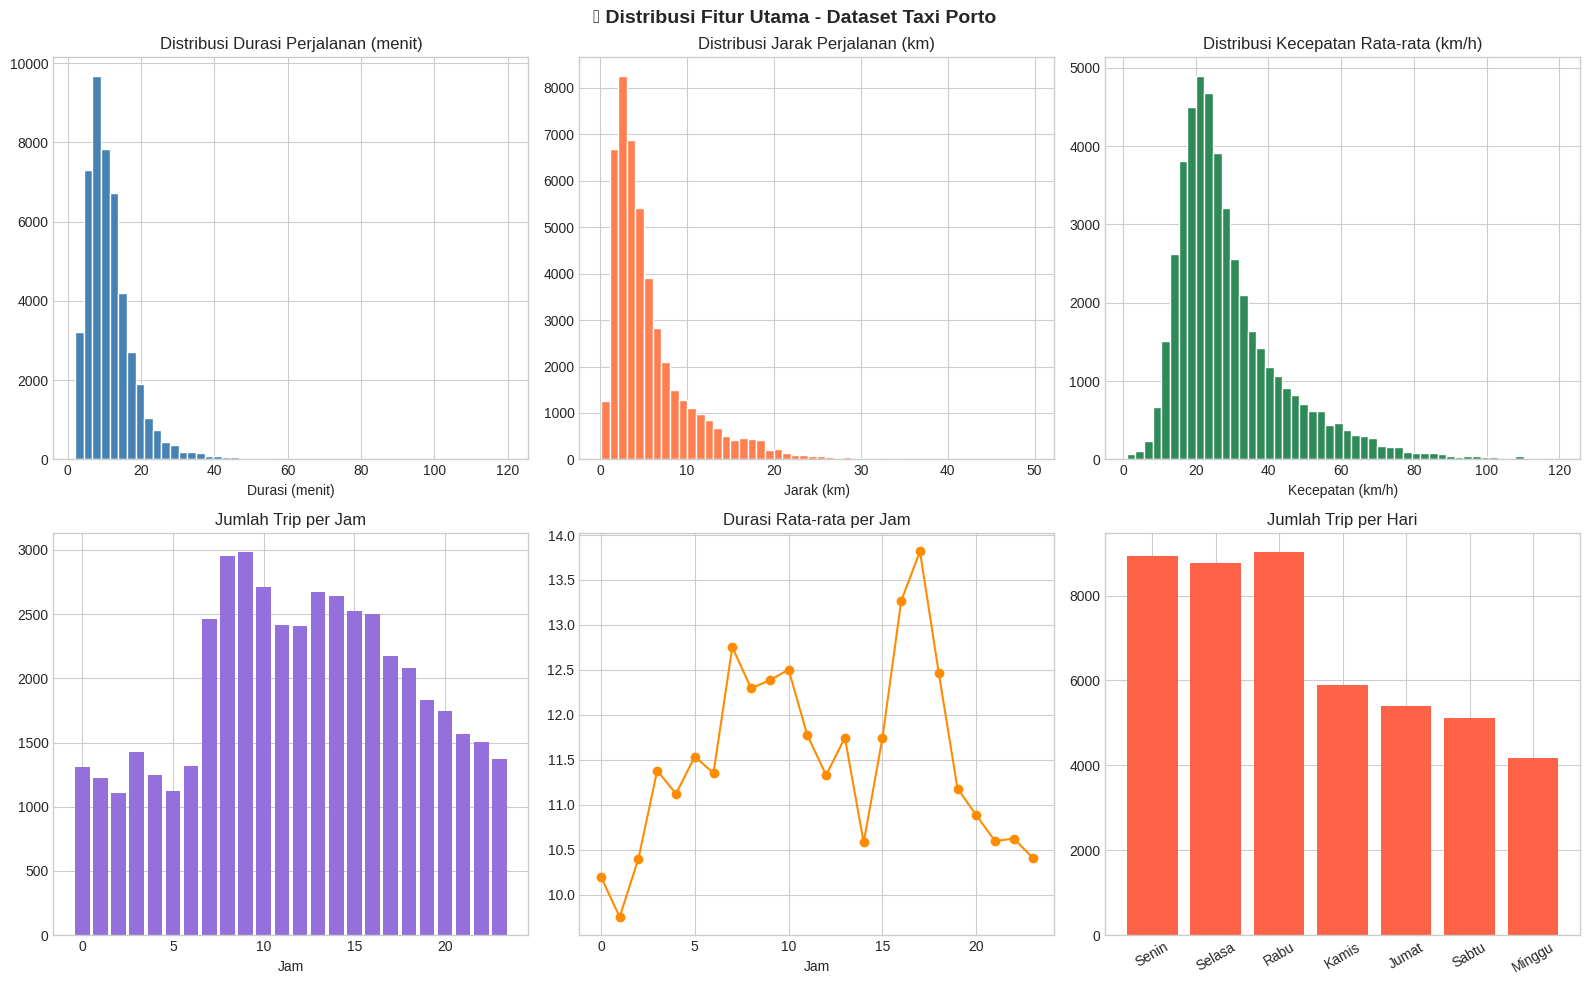

✅ Visualisasi disimpan!


In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('📊 Distribusi Fitur Utama - Dataset Taxi Porto', fontsize=14, fontweight='bold')

# 1. Distribusi durasi
axes[0,0].hist(df['duration_min'], bins=50, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribusi Durasi Perjalanan (menit)')
axes[0,0].set_xlabel('Durasi (menit)')

# 2. Distribusi jarak
axes[0,1].hist(df['distance_km'], bins=50, color='coral', edgecolor='white')
axes[0,1].set_title('Distribusi Jarak Perjalanan (km)')
axes[0,1].set_xlabel('Jarak (km)')

# 3. Distribusi kecepatan
axes[0,2].hist(df['avg_speed_kmh'], bins=50, color='seagreen', edgecolor='white')
axes[0,2].set_title('Distribusi Kecepatan Rata-rata (km/h)')
axes[0,2].set_xlabel('Kecepatan (km/h)')

# 4. Trip per jam
hour_counts = df['hour'].value_counts().sort_index()
axes[1,0].bar(hour_counts.index, hour_counts.values, color='mediumpurple')
axes[1,0].set_title('Jumlah Trip per Jam')
axes[1,0].set_xlabel('Jam')

# 5. Durasi rata-rata per jam
avg_dur_hour = df.groupby('hour')['duration_min'].mean()
axes[1,1].plot(avg_dur_hour.index, avg_dur_hour.values, marker='o', color='darkorange')
axes[1,1].set_title('Durasi Rata-rata per Jam')
axes[1,1].set_xlabel('Jam')

# 6. Distribusi per hari
day_names = ['Senin','Selasa','Rabu','Kamis','Jumat','Sabtu','Minggu']
day_counts = df['day_of_week'].value_counts().sort_index()
axes[1,2].bar([day_names[i] for i in day_counts.index], day_counts.values, color='tomato')
axes[1,2].set_title('Jumlah Trip per Hari')
axes[1,2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(f'{BASE_PATH}/data/eda_distribusi.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Visualisasi disimpan!')

## 8️⃣ Korelasi Antar Fitur

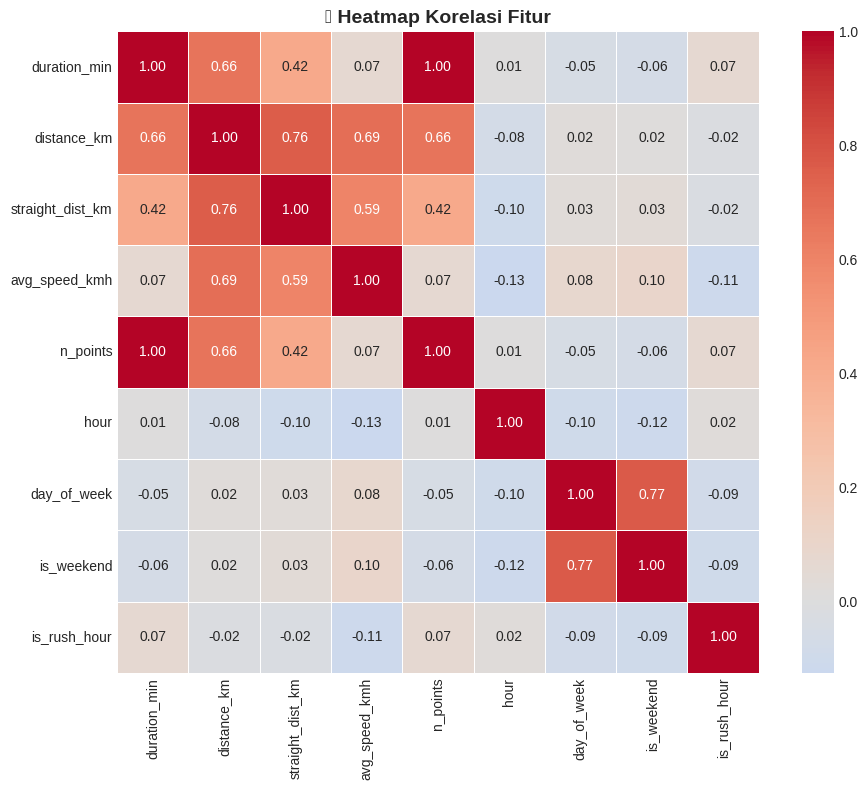

In [10]:
corr_cols = ['duration_min', 'distance_km', 'straight_dist_km', 'avg_speed_kmh',
             'n_points', 'hour', 'day_of_week', 'is_weekend', 'is_rush_hour']

corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5)
plt.title('🔥 Heatmap Korelasi Fitur', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{BASE_PATH}/data/eda_korelasi.png', dpi=150, bbox_inches='tight')
plt.show()

## 9️⃣ Simpan Data Hasil EDA

In [11]:
# Pilih kolom yang akan dipakai untuk modeling
feature_cols = [
    'start_lat', 'start_lon', 'end_lat', 'end_lon',
    'straight_dist_km', 'distance_km',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'is_rush_hour',
    'time_category', 'CALL_TYPE',
    'duration_min'  # TARGET
]

df_clean = df[feature_cols].copy()
df_clean.to_csv(f'{BASE_PATH}/data/data_clean.csv', index=False)

print(f'✅ Data bersih disimpan: {BASE_PATH}/data/data_clean.csv')
print(f'   Total baris: {len(df_clean):,}')
print(f'   Kolom: {df_clean.columns.tolist()}')
df_clean.head()

✅ Data bersih disimpan: /content/drive/MyDrive/ml-eta/data/data_clean.csv
   Total baris: 47,304
   Kolom: ['start_lat', 'start_lon', 'end_lat', 'end_lon', 'straight_dist_km', 'distance_km', 'hour', 'day_of_week', 'month', 'is_weekend', 'is_rush_hour', 'time_category', 'CALL_TYPE', 'duration_min']


,start_lat,start_lon,end_lat,end_lon,straight_dist_km,distance_km,hour,day_of_week,month,is_weekend,is_rush_hour,time_category,CALL_TYPE,duration_min
0,41.141412,-8.618643,41.154489,-8.630838,1.776808,2.651048,0,0,7,0,0,malam,C,5.5
1,41.159826,-8.639847,41.170671,-8.665740,2.480360,3.456269,0,0,7,0,0,malam,B,4.5
2,41.140359,-8.612964,41.140530,-8.615970,0.252442,17.630449,0,0,7,0,0,malam,C,16.0
3,41.151951,-8.574678,41.142915,-8.607996,2.965199,7.968045,0,0,7,0,0,malam,C,10.5
4,41.180490,-8.645994,41.178087,-8.687268,3.464589,4.814326,0,0,7,0,0,malam,C,7.0
